# QAOA Example (MaxCut)

This section demonstrates how to use the `cqlib-algorithm` to solve the MaxCut problem with the Quantum Approximate Optimization Algorithm (QAOA).

In [5]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions

print("Imports ready")

Imports ready


## 1. Define the MaxCut instance

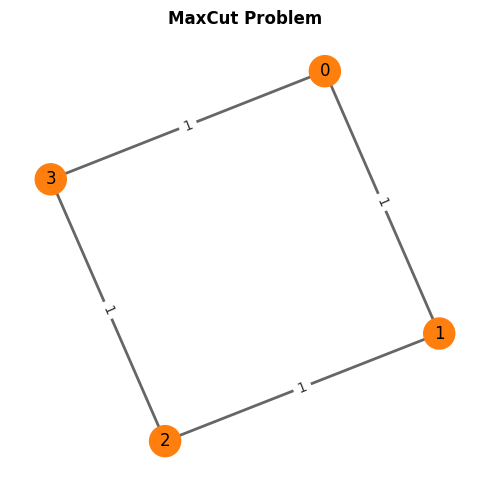

In [6]:
weights = {(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 0): 1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title="MaxCut Problem")

## 2. MaxCut → QUBO

In [8]:
qubo = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Maximize: - 2*x_0*x_1 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 2*x_0 + 2*x_1 + 2*x_2 + 2*x_3



## 3. QUBO → Ising

In [9]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. Run QAOA (LocalRunner)

[iter=  1] f=-0.544 theta=[0.318, 1.282, 0.318, -0.282, 0.682, -0.282]
[iter=  2] f=-0.208 theta=[0.557, 1.043, 0.557, -0.043, 0.921, -0.043]
[iter=  3] f=-0.234 theta=[0.600, 1.086, 0.600, -0.086, 0.878, 0.000]
[iter=  4] f=0.054 theta=[-0.048, 0.438, 1.248, -0.735, 1.526, -0.648]
[iter=  5] f=-0.998 theta=[-0.271, 0.661, 1.025, -0.512, 1.303, -0.871]
[iter=  6] f=-0.458 theta=[-0.142, 0.532, 0.896, -0.641, 1.174, -1.000]
[iter=  7] f=-0.496 theta=[-0.100, 0.573, 0.855, -0.682, 1.215, -0.958]
[iter=  8] f=-0.858 theta=[0.084, 0.757, 1.039, -0.499, 1.399, -0.775]
[iter=  9] f=-0.588 theta=[0.273, 0.568, 1.228, -0.309, 1.209, -0.964]
[iter= 10] f=-0.730 theta=[0.219, 0.622, 1.174, -0.363, 1.264, -1.019]
[iter= 11] f=-1.114 theta=[0.338, 0.503, 1.293, -0.244, 1.383, -0.899]
[iter= 12] f=-1.492 theta=[0.470, 0.634, 1.161, -0.113, 1.251, -0.768]
[iter= 13] f=-1.462 theta=[0.458, 0.646, 1.173, -0.124, 1.239, -0.780]
[iter= 14] f=-1.134 theta=[0.374, 0.730, 1.257, -0.041, 1.323, -0.696]
[ite

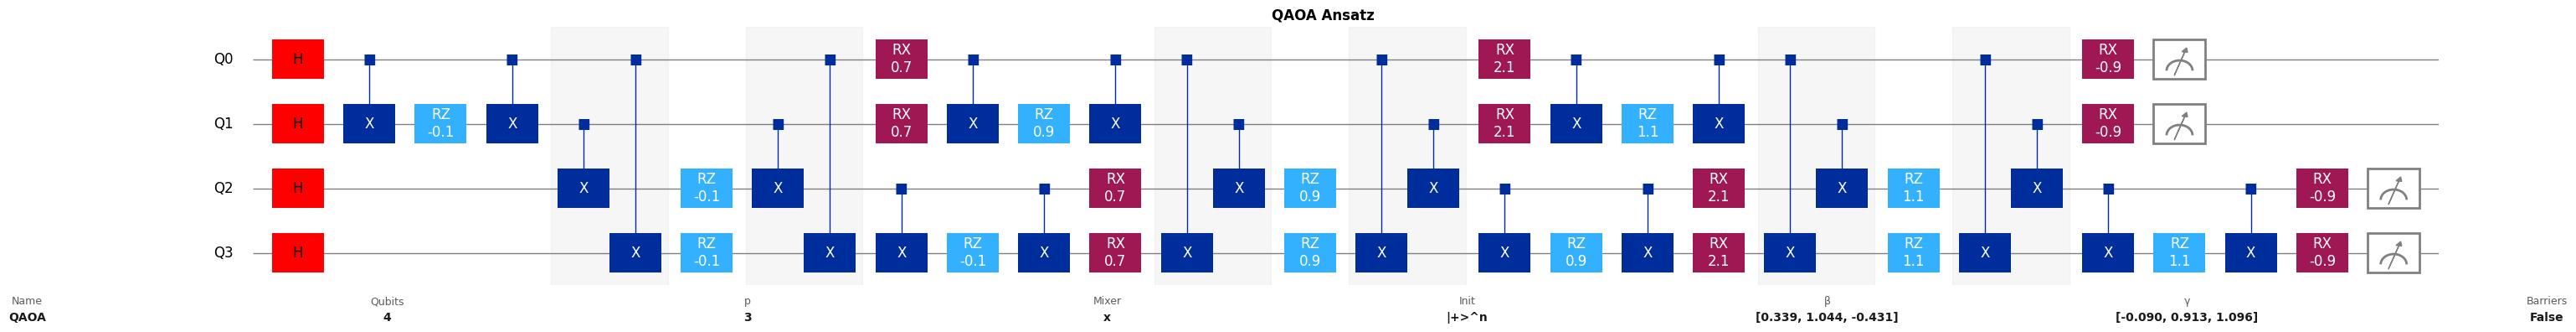

In [12]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 1000})
solver = QAOASolver(
    ising, runner=LocalRunner(), qaoa_cfg=QAOAConfig(reps=3, mixer="x"), opt_cfg=opt_cfg
)
res = solver.run()

## 5. Visualization: Results

In [13]:
res.print_result()


========== [ Experiment Information ] ==========
Task ID  : 20251030161618
Shots  : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 1000}}

========== [ Measurement Results ] ==========
probability : {'1010': 0.504, '0101': 0.496}


## 6. Visualization: Iteration Curve and Probability Distribution

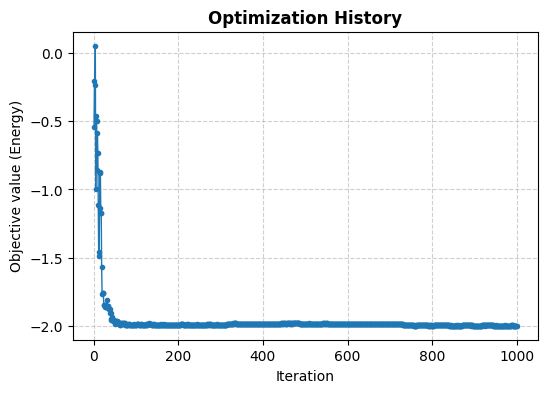

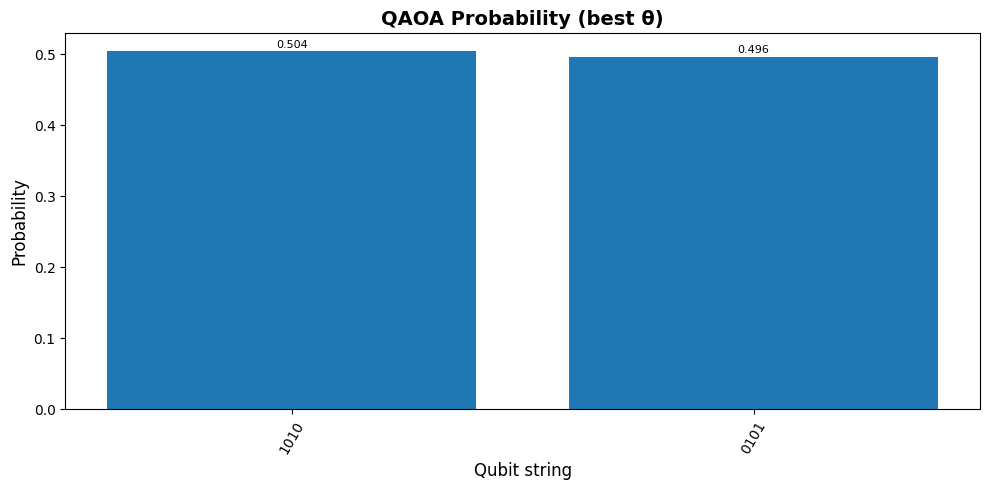

In [15]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. Visualization: Optimal MaxCut Solution


========== [ Optimization Results ] ==========
Best gammas : [-0.090, 0.913, 1.096]
Best betas  : [0.339, 1.044, -0.431]
Best energy : -2.000
Best Qubit string:  1010
Best solution: [0, 2]
Max-Cut value: 4.000


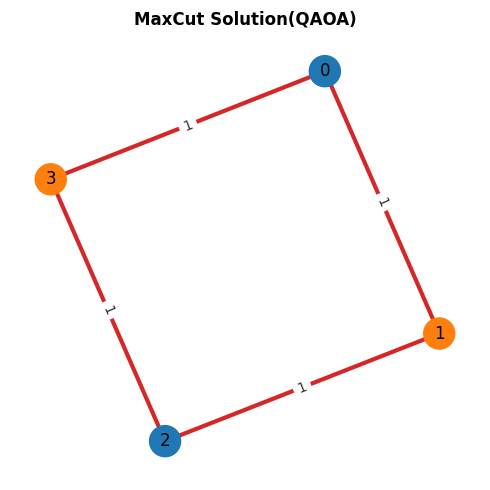

[0, 2]

In [16]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### Optional: Connect to China Telecom “TianYan” Quantum Computing Cloud Platform  
Replace `LocalRunner()` with `TianYanRunner()`:
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
